## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay,
                              confusion_matrix)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


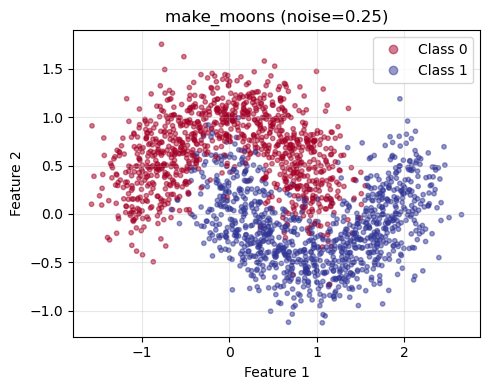

In [2]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [3]:
# 70/30 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

# Fit the scaler only on train data, transform only on X
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Training set : {X_train_s.shape[0]:,} tracts')
print(f'Test set     : {X_test_s.shape[0]:,} tracts')

Training set : 1,400 tracts
Test set     : 600 tracts


---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [4]:
# Create parameter grid
param_grid = {
    'C': [.001, .01, 0.1, 1, 10, 100]
}

# Grid search over parameters for best linear kernel configuration
grid_linear = GridSearchCV(
    SVC(kernel = 'linear', random_state = 42),
    param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

# Best parameters, CV accuracy, test accuracy 
grid_linear.fit(X_train_s, y_train)
best_linear = grid_linear.best_estimator_
linear_best_acc = accuracy_score(y_test, best_linear.predict(X_test_s))

print(f"Best parameters:  {grid_linear.best_params_}")
print(f"CV accuracy:      {grid_linear.best_score_}")
print(f"Test accuracy:    {linear_best_acc:.3f}")

Best parameters:  {'C': 1}
CV accuracy:      0.86
Test accuracy:    0.880


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [5]:
# Create data frame of accuracy values for each C
pd.DataFrame({
    'C': grid_linear.cv_results_['param_C'],
    'Mean Test Score': grid_linear.cv_results_['mean_test_score']
    })

,C,Mean Test Score
0,0.001,0.847143
1,0.01,0.853571
2,0.1,0.856429
3,1,0.860000
4,10,0.860000
5,100,0.860000


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

Cross-validation selected 1 as the best value for C. Because the moon boundary is curved, I would not expect the linear kernel to achieve a strong accuracy because the two classes within the data do not fit a linear pattern. The accuracy stops improving at at C=1, at 0.86. 

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [6]:
# Create parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1, 10]
}

# Grid search over parameters for best rbf kernel configuration
grid_rbf = GridSearchCV(
    SVC(kernel = 'rbf', random_state = 42),
    param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

# Best parameters, CV accuracy, test accuracy 
grid_rbf.fit(X_train_s, y_train)
best_rbf = grid_rbf.best_estimator_
svc_best_acc = accuracy_score(y_test, best_rbf.predict(X_test_s))

print(f"Best parameters:  {grid_rbf.best_params_}")
print(f"CV accuracy:      {grid_rbf.best_score_}")
print(f"Test accuracy:    {svc_best_acc:.3f}")

Best parameters:  {'C': 1, 'gamma': 1}
CV accuracy:      0.947857142857143
Test accuracy:    0.938


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The RBF kernel improves the cross validation accuracy significantly over the linear kernel, increasing from 0.86 to 0.948. The small value of 1 for C suggests a smoother boundary where more violations are tolerated. The relatively moderate value of 1 for gamma indicates a balance between a smooth, global boundary and a complex, local boundary.

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [7]:
# Create parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'degree': [2, 3, 4],
    'coef0': [0.0, 1.0]
}

# Grid search over parameters for best polynomial kernel configuration
grid_poly = GridSearchCV(
    SVC(kernel = 'poly', random_state = 42),
    param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

# Best parameters, CV accuracy, test accuracy 
grid_poly.fit(X_train_s, y_train)
best_poly = grid_poly.best_estimator_
svc_best_acc = accuracy_score(y_test, best_poly.predict(X_test_s))

print(f"Best parameters:  {grid_poly.best_params_}")
print(f"CV accuracy:      {grid_poly.best_score_}")
print(f"Test accuracy:    {svc_best_acc:.3f}")

Best parameters:  {'C': 1, 'coef0': 1.0, 'degree': 3, 'gamma': 1}
CV accuracy:      0.9450000000000001
Test accuracy:    0.940


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

GridSearch CV selected a degree 3 polynomial, with a slightly lower cross validation accuracy of 0.945 compared to the RBF kernel's 0.948. The test accuracy improved slightly by 0.002. The higher polynomial degree likely helped the boundary to curve enough to fit to the cresent-shaped data. A higher degree might not always help, because more degrees increase the risk of overfitting to the data and not generalizing well to unseen data and leading to a lower test accuracy.

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [8]:
# Create joint search of parameter grids
param_grid_all = [
    {
        'kernel': ['linear'],
        'C': [.01, 0.1, 1, 10, 100]
    },

    {
        'kernel': ['rbf'],
        'gamma': ['scale', .001, .01, 0.1, 1, 10],
        'C': [0.1, 1, 10, 100]
    },

    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', .001, .01, .1, 1],
        'degree':[2, 3, 4],
        'coef0': [0, 1]
    }
]

# Search over parameter grid for best configuration
grid_overall = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_grid_all,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

# Fit to scaled training data
grid_overall.fit(X_train_s, y_train)

best_overall = grid_overall.best_estimator_

test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_s))

# Print results
print(f"Best params:     {grid_overall.best_params_}")
print(f"CV Accuracy:     {grid_overall.best_score_:.3f}")

print(f"Test Accuracy:   {test_acc_overall:.3f}")

Best params:     {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV Accuracy:     0.948
Test Accuracy:   0.938


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The overall search selected the RBF kernel as the best one, which is consistent with the cross validation accuracies from the individual kernel results at the best score of 0.948. The RBF kernel fitting the data the best makes sense, because the RBF kernel allows for non-linearity in the cresent-shaped data, but did not overfit with a high polynomial degree.

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [9]:
# Parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

# Search over all values for best random forest configuration
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid_rf,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

grid_rf.fit(X_train_s, y_train)

best_rf = grid_rf.best_estimator_

test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test_s))

# Print results
print(f"Best params:     {grid_rf.best_params_}")
print(f"CV Accuracy:     {grid_rf.best_score_:.3f}")

print(f"Test Accuracy:   {test_acc_rf:.3f}")

Best params:     {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
CV Accuracy:     0.946
Test Accuracy:   0.938


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

The random forest test accuracy of 0.938 was the same as the test accuracy for the best SVM kernel, RBF. 

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

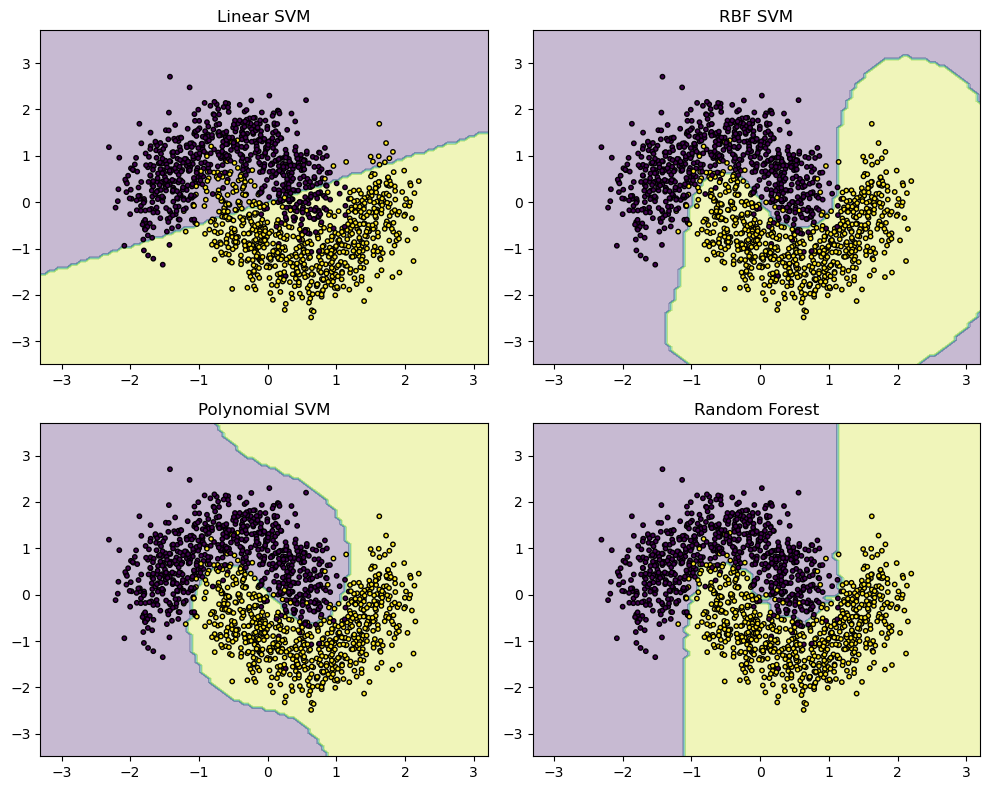

In [10]:
# Plot decision region for all four models
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Linear kernel
ax = axes[0, 0]
DecisionBoundaryDisplay.from_estimator(best_linear, X_train_s, ax=ax, response_method="predict", alpha=0.3)
ax.scatter(X_train_s[:, 0], X_train_s[:,1], c=y_train, s=10, edgecolors='k')
ax.set_title("Linear SVM")

# RBF kernel
ax = axes[0, 1]
DecisionBoundaryDisplay.from_estimator(best_rbf, X_train_s, ax=ax, response_method="predict", alpha=0.3)
ax.scatter(X_train_s[:, 0], X_train_s[:,1], c=y_train, s=10, edgecolors='k')
ax.set_title("RBF SVM")

# Polynomial kernel
ax = axes[1, 0]
DecisionBoundaryDisplay.from_estimator(best_poly, X_train_s, ax=ax, response_method="predict", alpha=0.3)
ax.scatter(X_train_s[:, 0], X_train_s[:,1], c=y_train, s=10, edgecolors='k')
ax.set_title("Polynomial SVM")

# Random forest model
ax = axes[1, 1]
DecisionBoundaryDisplay.from_estimator(best_rf, X_train_s, ax=ax, response_method="predict", alpha=0.3)
ax.scatter(X_train_s[:, 0], X_train_s[:,1], c=y_train, s=10, edgecolors='k')
ax.set_title("Random Forest")

plt.tight_layout()
plt.show()

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

The linear kernel is just a straight line that does not follow the shape of the data compared to the other three, which introduce some curving ability. The random forest boundary differs from the SVM boundaries because it adjusts the boundary a lot for individual points near the division line of the classes, and then becomes very straight and smooth after separating the center of the classes. 

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

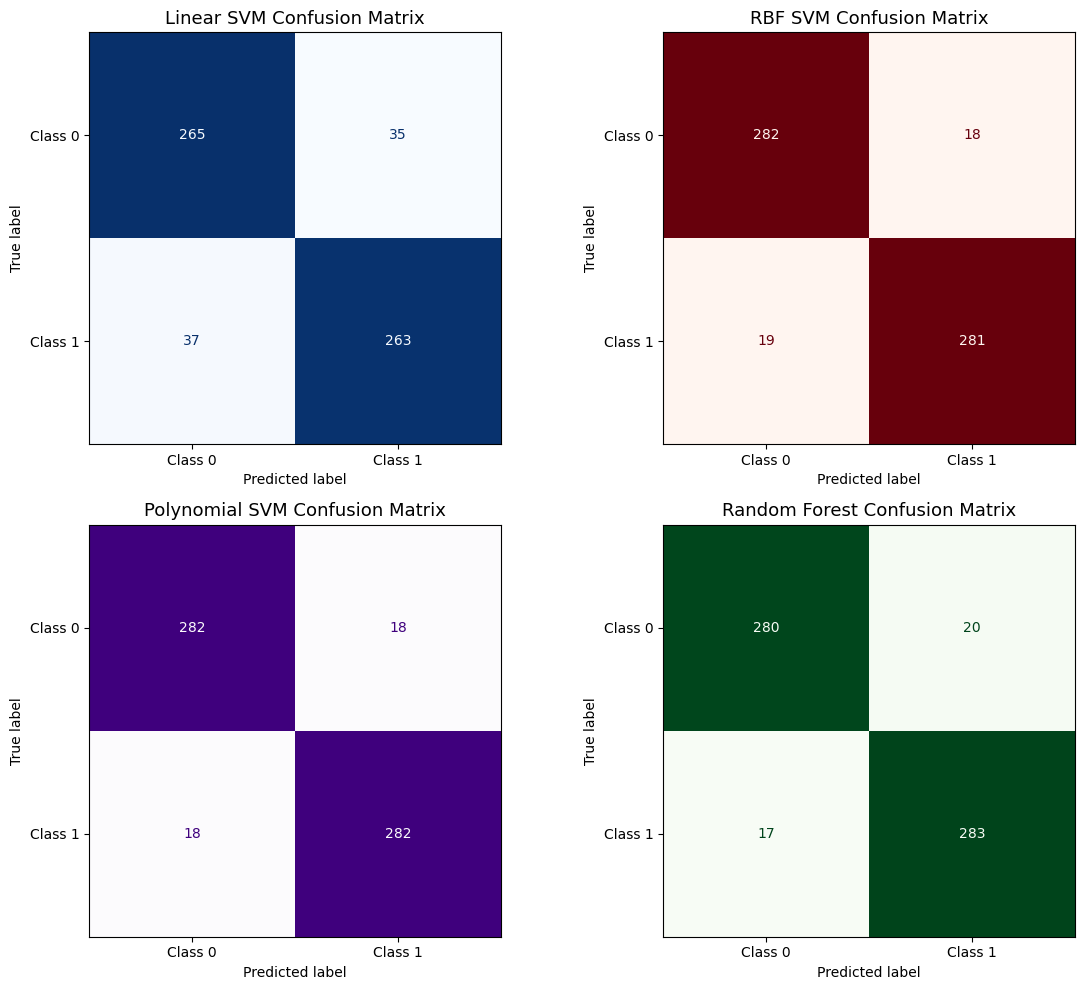

In [11]:
# List all four models
models = [
    (best_linear, "Linear SVM"),
    (best_rbf, "RBF SVM"),
    (best_poly, "Polynomial SVM"),
    (best_rf, "Random Forest"),
]

# Colors to match ROC curves
cmaps = ["Blues", "Reds", "Purples", "Greens"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Create each confusion matrix
for ax, (model, title), cmap in zip(axes.flatten(), models, cmaps):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_ylim(len(['Class 0', 'Class 1']) - 0.5, -0.5)
    ax.set_title(f'{title} Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.show()

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

The linear SVM confusion matrix misclassified more of each class, which makes sense as the data was cresent-shaped. The RBF and polynomial SVMs had very similar misclassifications, and the random forest had a few more false positives and a few less false negatives. 

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


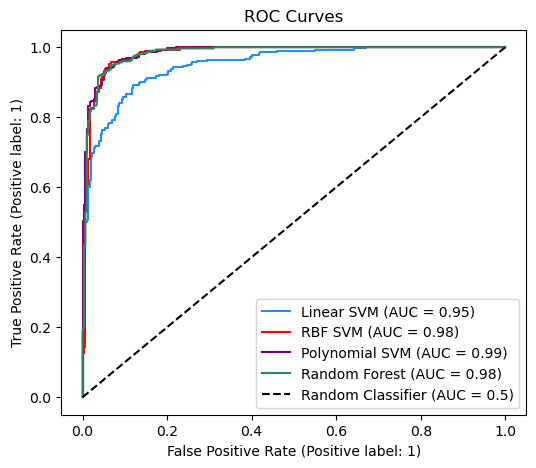

In [12]:
fig, ax = plt.subplots(figsize = (6,5))

# Linear kernel SVM
RocCurveDisplay.from_estimator(best_linear, X_test_s, y_test, name = "Linear SVM", ax = ax, color = 'DodgerBlue')

# RBF kernel SVM
RocCurveDisplay.from_estimator(best_rbf, X_test_s, y_test, name = "RBF SVM", ax = ax, color = 'red')

# Polynomial kernel SVM
RocCurveDisplay.from_estimator(best_poly, X_test_s, y_test, name = "Polynomial SVM", ax = ax, color = 'purple')

# Random forest 
RocCurveDisplay.from_estimator(best_rf, X_test_s, y_test, name = "Random Forest", ax = ax, color = 'seagreen')

# Line indicating random classifier 
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.legend()
ax.set_title('ROC Curves')
plt.show()

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

The AUC value for the polynomial SVM was slightly higher at 0.99 than the RBF and random forest at 0.98. The linear SVM had a lower AUC of 0.95 as expected based on the previous metrics. The AUC scores match the confusion matrices where the RBF SVM, polynomial SVM, and random forest has similar counts of false positives and false negatives. The random forest performs similarly to the polynomial and RBF SVM kernels across all three metrics, but has a blockier boundary compared to the smoother boundary of the SVM methods. If we wanted to know about feature importances for each variable, we might pick random forest because it performs very similarly to the other models, but in this case we don't have any actual context behind our data. Based upon the accuracy, AUC, and decision boundary shape, I would select the polynomial SVM kernel, because it seemed to fit the crescent shape of the classes well while not overfitting, and performed well consistently with accuracy scores and reducing misclassifications.

>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

The linear kernel did not perform as well as the other models because it had a high amount of bias, where a linear decision boundary would never fit this type of data. The latter models incorporate the ability to curve the line and capture non-linear decision boundaries, which improves the overall accuracy.